# Day 22: In-Class Assignment

___


### <p style="text-align: right;"> &#9989;&nbsp; **Put your name here** </p>
#### <p style="text-align: right;"> &#9989;&nbsp; Put your group member names here</p>

## Bootstrap and confidence intervals: urban birds and seed rains

<img src="https://www.pbs.org/wnet/nature/files/2019/02/stock-photo-pigeons-in-the-city-of-new-york-64643284-1920x1280.jpg" style="display:block; margin-left: auto; margin-right: auto; width: 55%" alt="Picture of several pigeons sitting on a steel barrier in a city. Various skyrises can be seen on the background.">
<p style="font-size:0.85em; text-align: center;">Credits: <a href="https://www.pbs.org/wnet/nature/asl/celebrate-urban-birds/" target="_blank">PBS</a></p>

### Learning goals of today's assignment

* Recap how to use bootstrap to compute confidence intervals whenever a formula is not immediately available
* Use SciPy to do bootstrap confidence intervals under the hood

## Assignment instructions

Work with your group to complete this assignment. Instructions for submitting this assignment are at the end of the Notebook. The assignment is due at the end of class.

___

## Importing the modules that we will need

Before we start anything, it is good practice to have all our imports as the first Python cell

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from sklearn import metrics

---

## 1. Predicting bird diversity in urban settings

(This is the same text as in Homework 04)

There is a wealth of satellite data out there. With it, we can compare large swaths of land and environments at once, which can improve our biodiversity predictions. The normalized difference vegetation index (NDVI)&mdash;a widely used index captured by satellite cameras to determine "plant green-ness"&mdash;often shows positive relationships with bird diversity. However, its reliability as a predictor across contrasting urban contexts remains uncertain. 

You will examine the relationships between the NDVI and bird species richness across three cities&mdash;Columbia MO (USA), Xalapa (Mexico), and MedellÃ­n (Colombia)&mdash;using Landsat-8 satellite imagery with buffer distances of 200m. Think of "camera focus settings" if you're unfamiliar with buffer distances.

All the data is taken from:

> MacGregor-Fors, I, GarizÃ¡bal-Carmona, JA, GarcÃ­a-Arroyo, M, Fishel, E, Nilon, CH, Lemoine-RodrÃ­guez, R (2026) [Does NDVI explain patterns of urban bird diversity? Insights from temperate to tropical cities](https://doi.org/10.1016/j.ufug.2025.129211). *Urban Forestry &amp; Urban Greening* **116**: 129211.


<img src="https://ars.els-cdn.com/content/image/1-s2.0-S161886672500545X-gr2_lrg.jpg" style="display:block; margin-left: auto; margin-right: auto; width: 70%" alt="Relationships between bird species richness and NDVI values highlighting the extreme scenarios (weakest and strongest) for visualization purposes. We selected these extreme scenarios based on the coefficient of determination (r2, see Table 1) at the 50 buffer using Sentinel-2. We also included MedellÃ­n, with intermediate values, to provide the full comparative picture.">
<p style="font-size:0.85em; text-align: center;">Credits: <a href="https://doi.org/10.1016/j.ufug.2025.129211" target="_blank">MacGregor-Fors et al (2026)</a></p>

&#9989;&nbsp; **Question 1**

- What is reflected on the x-axis?
- What is reflected on the y-axis?
- In your own words, what information do you get out of this figure?

<font size=+3>&#9998;</font> *Put your answer here*

### 1.1 Data loading and wrangling (2pt)

&#9989;&nbsp;  **Task 2**

- Load the `'Bird_Richness_NDVI_Woody_Pages7-20.xlsx'` file (attached in Canvas). Notice that it is an Excel file, not a CSV.
- Display the first few rows to make sure it looks good. It should be 405 rows and 15 columns long.

In [2]:
# Load with pandas

Things to keep in mind: Each row represents a different geographical **Point**:

- **City**: The city where the data comes from.
- **BR**: Bird-richness index: the higher means larger diversity of birds species.
- **L8**: NDVI data from the Landsat-8 satellite.
- For both satellites, we have 4 buffer distances (camera resolutions): **50m**, **100m**, **200m**, and **400m**.

&#9989;&nbsp; **Task 2 (continued)**

- Mask and make a subDataFrame looking only at the data from Columbia.
- **We will work with this subdataframe from hereafter**

In [3]:
# Your subdataframe

### 1.2 Correlations

Let's check if bird richness in Columbia is correlated to NDVI according to **Landsat-8** data with **200 meters** buffer distance.

&#9989;&nbsp; **Task 3**

- Make a scatter plot of NDVI versus bird richness.
    - It will be easier down the road if you use Axes objects instead of pyplot (which is what we used for Days 20 and onward).
- Remember to add x- and y-axes labels.
    - It will be easier for the next task if you [use `.supxlabel()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.supxlabel.html) and [`.supylabel()` instead](https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.supylabel.html) of `.set_xlabel()` and `.set_ylabel()` respectively.

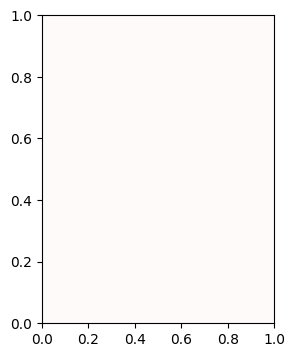

In [4]:
# Complete the scatterplot
fig, ax = plt.subplots(1,1, figsize=(3,4), sharex=True, sharey=True) # Use Axes `ax` instead of pyplot
ax = np.atleast_1d(ax) # Make sure ax is an array (by default, it is NOT when making a 1 x 1 subplot)

# Color the background ever so slightly
ax[0].set_facecolor('snow')

# Uncomment and complete
#ax[0].scatter() 

&#9989;&nbsp; **Question 4**

- From the scatter plot alone, do you think NDVI is a good predictor of bird richness in Columbia?

<font size=+3>&#9998;</font> *Put your answer here.*


&#9989;&nbsp; **Task 5**

Now compute and print both the Pearson and Spearman correlation coefficients along their respective p-values.

In [5]:
# Your code

&#9989;&nbsp; **Question 6**

- Are Pearson and Spearman coefficients quite different or quite similar?
- What conclusion do you draw by looking at both of them? Does it match your intuition from Q4?

<font size=+3>&#9998;</font> *Put your answer here.*


### 1.3 Confidence intervals for Pearson's correlation: the `PearsonRResult` object

Confidence intervals are not limited to means: we can also compute confidence intervals for the Pearson's $r$. Its interpretation is the same as the CI for means:

> Pearson's 95% confidence interval is an interval that will contain the true Pearson's $r$ 95% of the times.
>
> Said other way: if we were to repeat our experiment 100 times&mdash;we grab 100 samples&mdash;, the 95% CI contains the $r$ from at least 95 experiments.

The formula to compute a Pearson's $r$ confidence interval is [quite complicated, though](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient#Using_the_Fisher_transformation) This is because, unlike a normal distribution, Pearson's $r$ can never go outside the $[-1, 1]$ range.

The good news is that SciPy already does all the math for us. The `stats.pearsonr` returns actually a `PearsonRResult` object. [Check the `Returns` section of `stats.pearsonr`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html).

```python
pearsonr = stats.pearsonr( x_variable, y_variable ) 
print(pearsonr)

# PearsonRResult(statistic=<r value>, pvalue=<p value>)
# As you have done before, we can then get the r coefficient by doing
# pearsonr.statistic
#
# And the p-value by doing
# pearsonr.pvalue

# But we can also get a confidence interval by doing
ci = pearsonr.confidence_interval(confidence_level = alpha)
print(ci.low, ci.high)
# It does 95% CI by default
```

&#9989;&nbsp;  **Task 7**

- Compute and print the Pearson's correlation 95% confidence interval for the NDVI versus bird richness data above.
- Also print the 99% CI.

In [6]:
# Your code

&#9989;&nbsp; **Question 8** 

- Do the confidence inteval values change or reinforce your hypothesis from Q4?
- If you were a consultant for Columbia's bird conservancy group, would you advise them to invest in NDVI data collection and analysis?

<font size=+3>&#9998;</font> *Put your answer here.*


### 1.4 Confidence intervals for Spearman's correlation: bootstrapping

But what about Spearman's $\rho$ coefficient? We have two bad news. 

+ `stats.spearmanr` [does **not** return an object](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html) that can compute confidence intervals for us.
+ The math behind Spearman's confidence intervals is even [more exotic](https://stats.stackexchange.com/a/506367/301949).

But we have one good news: **we can bootstrap**. Recall the steps:

1. Generate a new samples from our original measurements by sampling with replacement
   - In this case, we consider a `(ndvi_value, br_value)` pair as a single point.
1. Compute and save the Spearman's coefficient
1. Repeat steps 1-2 a lot of times (like $N = 1000$)
1. Get the $(1-\alpha)/2$ and $(1+\alpha)/2$ quantiles of all the Spearman's coefficients

&#9989;&nbsp;  **Task 9**

The tricky part is to bootstrap a *pair* of measurements instead of a single one, as we did back in Day 19. A strategy is to sample (with replacement) a set of *indices* instead. Then we use those indices to get both NDVI and BR values.

- Use [the `rng.integers` function](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.integers.html) to generate a random array of integers between 0 and `<length of NDVI data>`. It must have `size` of `<length of NDVI data>`.
- Save such array of random numbers as a `random_indices` variable.
- Use the array to get the corresponding NDVI and BR values
    - For example, you might want to do `ndvi[random_indices]` if `ndvi` is an array
    - Or `ndvi.iloc[random_indices]` if it is a Series
- Compute the Spearman's correlation coefficient with your new sampled values

In [7]:
# Your code

rng = np.random.default_rng(42)

&#9989;&nbsp;  **Task 10**

Now put things on a loop:

- Make an array [with `np.zeros`](https://numpy.org/doc/stable/reference/generated/numpy.zeros.html) where you'll save Spearman coefficients.
- In a loop:
   - Make a new random set of indices like in T9
   - With the indices, get a sample of NDVI values and their corresponding BR values
   - Compute and save the spearman correlation
   - Repeat $N = 1000$ times

In [8]:
# Your code

N = 1000

&#9989;&nbsp;  **Task 11**

- Now [use `np.quantile`](https://numpy.org/doc/stable/reference/generated/numpy.quantile.html) to get and print the quantiles corresponding to the 95% confidence interval ($\alpha = 0.95$).
- Print the 99% CI as well.

In [9]:
# Your code

&#9989;&nbsp; **Question 12** 

- Do the confidence inteval values make sense?
- How do they compare to the CIs from Pearson? Is this like in Q6?

<font size=+3>&#9998;</font> *Put your answer here.*


---

## 2. Seed rainfall in Northern Missouri praires [Time-permitting]

(This is the same text from Homework 04)

Let's switch gears. For this part, the research quantifies patterns of seed rain&mdash;the process of seeds falling from plants to the soil&mdash;in a remnant tallgrass prairie and various stages of restored prairies. It reveals that young prairies produce significantly more seed rain than previously understood. The study found distinct changes in seed rain metrics as prairies aged, with the oldest restorations showing comparable quantities to the remnant prairie, but lacking in species composition. The findings suggest that increasing seeding rates of desirable species may be necessary to enhance restoration outcomes.

More details and data on:
> Wynne, KC, Parker-Smith, MJ, Murdock, EM, & Sullivan, LL (2024) [Quantifying seed rain patterns in a remnant and a chronosequence of restored tallgrass prairies in north central Missouri](https://doi.org/10.1111/1365-2664.14806). *Journal of Applied Ecology*, **61**: 3017&ndash;3027

The goal is to reproduce Figure 1b:

<img src="https://besjournals.onlinelibrary.wiley.com/cms/asset/579f2632-b69f-44bb-99cd-e47e0f63f20a/jpe14806-fig-0001-m.jpg" style="display:block; margin-left: auto; margin-right: auto; width: 90%" alt="The number of seeds, (b) seed rain biomass (mg) and (c) CWM seed mass (mg) captured per transect in the remnant prairie in 2019 (dark green), young (2-year-old, dark blue), middle-aged (5-6-year-old, light blue) and old (15-year-old, light green) reconstructed prairies. Error bars represent 95% confidence intervals around model estimates (black). Asterisks indicate sites with significant differences from the remnant prairie (pâ<â0.05).">
<p style="font-size:0.85em; text-align: center;">Credits: <a href="https://doi.org/10.1111/1365-2664.14806" target="_blank">Wynne et al (2024)</a></p>

&#9989;&nbsp; **Question 13: Just looking a Figure 1b**

- What is reflected on the x-axis?
- What is reflected on the y-axis?
- In your own words, what information do you get out of this figure?

<font size=+3>&#9998;</font> *Put your answer here*

### 2.1 Data loading

&#9989;&nbsp; **Task 14**

- Load the `'Seed_Rain_Traits_Dataset.csv'` file (attached in Canvas). Notice that it is an Excel file, not a CSV.
- Display the first few rows to make sure it looks good. It should be 4275 rows and 8 columns long.

In [10]:
# Your code

Important columns and information:

* **Plot**: Prairie type
     * PFCA 1 = Young-aged restored prairie
     * PFCA 2 = Middle-aged restored prairie
     * PFCA 3 = Old-aged restored prairie
     * TP = remnant prairie in 2019
* **Transect**: Corresponding transect number at a site (10 per site).
* **Number**: The number of seeds collected from traps.
* **TotWeight**: Total seed rain biomass (mg)

&#9989;&nbsp; **Task 15**

- With your original DataFrame, group the rows by prairie age (`Plot`) *and* transect
- Compute the total biomass of seeds for each prairie age&ndash;transect combination. Remember pandas has a [`.sum` function](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.sum.html).
- Use the `as_index=False` parameter to obtain a DataFrame instead of a Series.
- The first five rows should read something like:

| |Plot| 	Transect |	TotWeight|
|-:|--:|--:|--:|
|**0**| 	PFCA 1| 	1| 	2973.886640|
|**1**| 	PFCA 1| 	2| 	4920.950468|
|**2**| 	PFCA 1| 	3| 	6435.186945|
|**3**| 	PFCA 1| 	4| 	4836.356308|
|**4**| 	PFCA 1| 	5| 	6052.586332|

In [11]:
# Your code

&#9989;&nbsp; **Task 16**

Peform *three* t-tests to check if the seed counts from restored prairies (`PFCA 1`, `PFCA 2`, `PFCA 3` for young, middle aged, and old, respectively) are different compared to remnant prairies (`TP`).

- Mask your DataFrame from Task 15 appropriately
- Print your t-test results

In [12]:
# Your tests

&#9989;&nbsp; **Question 17**

- Based on your results above, what do you think is the relationship&mdash;if any&mdash;between prairie restoration age and seed counts?

<font size=+3>&#9998;</font> *Put your answer here*

&#9989;&nbsp; **Task 18**

But the p-values alone might not tell the full picture. Now make a jitterplot to confirm or reject your thoughts. Before that, make a summary of your summary.

Make a new DataFrame that is a summary of the one in T15: you want the seed biomass mean, SE, and sample size for each prairie age
- Group rows by `Plot`
- Get the seed biomass mean, SE, and sample size (`count`) for each age
- Display your new summary

In [13]:
# Your code here

&#9989;&nbsp;  **Task 19**

- Use the values in your T18 DataFrame and append to it **two** new columns with the lower and upper 95% confidence intervals of the mean.
- Remember to set `as_index = False`

In [14]:
# Your code

alpha = 0.95

&#9989;&nbsp; **Task 20**

- Like Figure 1(b), make a jitterplot where different columns correspond to different restoration ages
- Uncomment and edit the lines to plot the mean biomass along the 95% CI like in Wynne et al (2024)
- Remember that the indices of your summary-summary DataFrame (from T19) are conveniently `0, 1, 2, 3`
- Label the x- and y-axes

In [15]:
# Your plot

fs = 12
rng = np.random.default_rng(42)
nudge = rng.uniform(-0.15, .15, 10000)

# for i in range(len(<summary dataframe>)):
    #ax.scatter([i], [summary.loc[i, 'mean']], c='k', s=75, zorder=2)
    #ax.plot([i,i], [summary.loc[i, 'low_ci'], summary.loc[i, 'high_ci']], c='k', marker='_', ms=10)

&#9989;&nbsp; **Question 21**

- Does the visualization match your thoughts from Q17?
- If you were a consultant for a conservancy NGO, what would you tell them about waiting times to see some true restoration taking place?

<font size=+3>&#9998;</font> *Put your answer here*

---

## Congratulations, you're done!

Submit this assignment by uploading it to the course Canvas web page.  Go to the "In-class assignments" folder, find the appropriate submission link, and upload it there.

See you next class!

&#169; Copyright 2026,  Division of Plant Science & Technology&mdash;University of Missouri